<div align="center">

<h1> <b> UNIFIED MONTE CARLO FRAMEWORK AND STATISTICAL VALIDATION OF THIN FILM GROWTH </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara <br>
Juan Palacio <br>
Sofía Moscoso <br>
Lucas Perdomo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---


# 1. Introducción teórica y marco de la física estadística

Este documento constituye el núcleo unificado y la síntesis cuantitativa del estudio de la cinética de crecimiento de películas delgadas de cobre ($Cu$) mediante simulación estocástica Monte Carlo. El objetivo fundamental de la física de interfaces es comprender cómo las fluctuaciones a escala atómica durante la deposición física de vapor (PVD) escalan macroscópicamente hasta definir la rugosidad, la porosidad y la homogeneidad de un recubrimiento industrial (Ohring, 2002).

A diferencia de los modelos analíticos macroscópicos, el enfoque unificado que se desarrolla en este cuaderno integra, dentro de un mismo motor computacional, las ecuaciones cinéticas de transporte en fase gaseosa con las leyes termodinámicas moleculares que gobiernan la superficie del sustrato.

## 1.1 Mecanismos físicos en competencia

La morfología final de una película delgada está gobernada por un balance continuo entre dos tipos de fenómenos antagónicos:

1. **Mecanismos desestabilizadores (transporte y geometría):**
   * *Inyección angular oblicua:* los átomos no inciden de forma estrictamente vertical. La desviación angular inicial ($\sigma_{\text{init}}$) rompe la simetría del flujo e induce componentes de velocidad lateral (Nieuwenhuizen & Haanstra, 1966).
   * *Sombreado balístico (shadowing):* es un mecanismo de retroalimentación positiva geométrica, dominante en condiciones de alto vacío (UHV). Las regiones microscópicas que por azar quedan más altas interceptan con mayor probabilidad el flujo de vapor entrante, bloqueando la llegada de material a los valles adyacentes. Esto dispara una inestabilidad cinemática que genera estructuras columnares y porosidad extrema (Karunasiri et al., 1989).

2. **Mecanismos estabilizadores (termodinámica y atenuación):**
   * *Relajación superficial (difusión térmica):* una vez que un adátomo colisiona con la película, utiliza la energía térmica del sustrato ($T$) para superar barreras locales y migrar lateralmente hacia sitios de menor energía potencial, típicamente valles o huecos con mayor número de coordinación (Arrhenius, 1889; Venables, 2000). Este proceso actúa como un filtro de paso bajo que suaviza la rugosidad de alta frecuencia espacial.
   * *Dispersión gaseosa (scattering por presión):* la introducción de un gas de arrastre inerte reduce el camino libre medio ($\lambda$, MFP) de la cámara. Las colisiones moleculares desvían las trayectorias balísticas estrictas de las partículas y convierten el flujo en semidifusivo, lo que permite que los átomos se desvíen hacia el interior de las zonas sombreadas y amortigüen la inestabilidad columnar (efecto de anti-shadowing).

## 1.2 Teoría de escalamiento dinámico: la ley de Family-Vicsek

Para abandonar la inspección puramente visual y cuantificar la naturaleza estadística de cada frente de crecimiento, se recurre a la teoría de escalamiento dinámico (Family & Vicsek, 1985). Una interfaz en crecimiento es un sistema fuera del equilibrio térmico, autorregulado por leyes de potencias universales.

La métrica fundamental es la rugosidad superficial RMS ($W$), definida como la desviación estándar de la función de alturas $h(x,y)$:

$$W(L, \overline{h}) = \sqrt{\frac{1}{L^2} \sum_{i,j}^L \left[ h(i,j) - \overline{h} \right]^2}$$

donde $L$ es el tamaño de la malla ($NX \times NY$) y $\overline{h}$ es el espesor medio de la película, que actúa como métrica lineal del tiempo físico de deposición.

Según la relación de escala de Family-Vicsek, en un sustrato suficientemente grande y antes de que los efectos de tamaño finito saturen el sistema, la rugosidad crece siguiendo una ley de potencias respecto al espesor:

$$W(\overline{h}) \propto \overline{h}^\beta$$

donde $\beta$ es el exponente de crecimiento dinámico. Aplicando logaritmo natural a la relación de escala se obtiene una ecuación lineal:

$$\ln(W) = \beta \ln(\overline{h}) + C$$

de modo que, al realizar una regresión lineal en el espacio log-log, la pendiente de la recta entrega directamente el exponente $\beta$.

## 1.3 Criterios cuantitativos y clases de universalidad

El valor numérico de $\beta$ permite clasificar cada régimen de crecimiento dentro de familias matemáticas de comportamiento bien definidas, o clases de universalidad (Barabási & Stanley, 1995). Para una interfaz que crece sobre un sustrato bidimensional, como la malla $NX \times NY$ empleada en este trabajo, los valores de referencia son:

* **$\beta = 0.50$ (Random Deposition, RD):** azar estocástico puro, sin correlación espacial entre columnas vecinas. La rugosidad diverge indefinidamente como la raíz cuadrada del espesor.
* **$\beta \to 0$, o $\beta \approx 0.24$–$0.25$ (clases Edwards-Wilkinson / KPZ):** domina la difusión y la minimización de energía superficial. El crecimiento satura relativamente rápido y genera frentes compactos, deseables para barreras protectoras de crecimiento capa por capa.
* **$\beta > 0.50$ (crecimiento columnar / sombreado):** el transporte geométrico domina sobre la termodinámica. La película es inestable, altamente porosa y desarrolla desfiladeros geométricos abruptos.

El régimen óptimo para una aplicación industrial depende del objetivo: los recubrimientos planos exigen $\beta \to 0$, mientras que las aplicaciones catalíticas o sensoras que requieren alta área superficial se benefician de regímenes inestables con $\beta > 0.50$.


# 2. Objetivos del estudio

1. **Integración modular completa:** consolidar en un único motor computacional unificado, optimizado mediante Numba JIT, las variables físicas distribuidas a lo largo de los notebooks 1 a 6 (ángulo de incidencia, difusión molecular, temperatura, sombreado balístico y presión de cámara).
2. **Mitigación estocástica:** ejecutar suites estadísticas masivas (25 réplicas independientes por modelo) para reducir el ruido propio del método Monte Carlo y aislar las curvas cinéticas deterministas de cada régimen.
3. **Extracción del exponente de crecimiento ($\beta$):** programar un algoritmo de regresión lineal en el espacio logarítmico de Family-Vicsek para calcular numéricamente el exponente $\beta$ de cada modelo y contrastarlo con las predicciones teóricas de la física del estado sólido.
4. **Criterios de selección industrial:** construir una matriz cuantitativa basada en la rugosidad final ($W_{\text{final}}$), el rango pico-valle ($\Delta H$) y el exponente $\beta$, que permita parametrizar de forma predictiva el comportamiento de un reactor de vacío real.


In [14]:
# =============================================================================
# SECCIÓN 3: CONFIGURACIÓN DEL ENTORNO DE CÓMPUTO Y ESTILO GRÁFICO
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numba as nb
import time
import scipy.stats as stats

# Semilla global de referencia. Las corridas individuales dentro de la suite
# estadística (Sección 7) resiembran el generador con un valor distinto por
# réplica, de modo que esta llamada solo fija el estado inicial documentado.
np.random.seed(42)

# Estilo gráfico institucional para las figuras del informe
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.titlesize': 14,
    'font.family': 'serif',
    'figure.dpi': 130
})


In [15]:
# =============================================================================
# SECCIÓN 4: PARÁMETROS OPERACIONALES GLOBALES DEL REACTOR SIMULADO
# =============================================================================

# Dimensiones espaciales fijas del sustrato de análisis (malla cuadrada NX x NY)
NX = 200
NY = 200

# Parámetros estocásticos comunes a todos los modelos de la suite comparativa
N_EVENTOS_COMPARATIVA = 160000  # Átomos inyectados por cada corrida completa
GUARDAR_CADA = 2000              # Frecuencia de muestreo de la cinética temporal

# Variables termodinámicas y de transporte, heredadas de los valores de
# referencia establecidos en los notebooks 4 a 6
TEMP_ALTA = 400                 # Temperatura del sustrato para los modelos térmicos (K)
MAX_PASOS_DIFUSION = 5           # Máximo de saltos de relajación superficial por adátomo
SIGMA_INCIDENCIA_INIT = 15.0     # Desviación angular de emisión en la fuente (grados)
SIGMA_SCATTERING_GAS = 20.0      # Desviación angular inducida por cada colisión con el gas (grados)
MFP_PRESION_INTERMEDIA = 10.0    # Camino libre medio representativo del caso con gas (unidades de malla)


In [16]:
# =============================================================================
# SECCIÓN 5: ARQUITECTURA DEL MOTOR COMPUTACIONAL MODULAR (NUMBA JIT)
# =============================================================================
# El motor se organiza en tres bloques que se ensamblan en un único lazo de
# deposición: (1) transporte en fase gaseosa desde la fuente hasta el
# sustrato, (2) relajación térmica superficial del adátomo recién llegado, y
# (3) cómputo de los observables morfológicos de la superficie. Cada
# mecanismo físico (ángulo de incidencia, sombreado, dispersión por gas,
# difusión térmica) se activa o desactiva mediante banderas booleanas, lo que
# permite reproducir cualquiera de los regímenes de los notebooks 1 a 6 con
# un único conjunto de funciones compiladas.

@nb.njit
def calcular_estadisticos_superficie(superficie, nx, ny):
    """
    Calcula el espesor medio y la rugosidad RMS de la superficie depositada.

    El espesor es la altura promedio de la malla; la rugosidad es la
    desviación estándar poblacional de las alturas respecto a ese promedio,
    consistente con la definición de W(L, h̄) de la Sección 1.2.
    """
    suma_h = 0.0
    for i in range(nx):
        for j in range(ny):
            suma_h += superficie[i, j]
    espesor = suma_h / (nx * ny)

    suma_var = 0.0
    for i in range(nx):
        for j in range(ny):
            diff = superficie[i, j] - espesor
            suma_var += diff * diff
    rugosidad = np.sqrt(suma_var / (nx * ny))
    return espesor, rugosidad


@nb.njit
def modulo_transporte_fase_gaseosa(nx, ny, superficie, max_h_actual, sigma_init, sigma_scat, mfp,
                                    enable_angle, enable_scattering, enable_shadowing):
    """
    Módulo de transporte unificado del adátomo entre la fuente y el sustrato.

    Controla de forma selectiva tres fenómenos: la inclinación angular de
    emisión, las colisiones con el gas residual de la cámara y el sombreado
    balístico por el relieve ya depositado. `max_h_actual` es la altura
    máxima de la superficie previa a este evento, que el llamador mantiene de
    forma incremental para evitar recorrer la malla completa en cada evento.
    """
    # El techo de emisión se ubica 40 unidades sobre el punto más alto de la
    # superficie cuando el sombreado está activo, para que la topografía
    # existente pueda interceptar la trayectoria; en caso contrario se usa
    # una distancia de vuelo fija, como en los modelos sin sombreado.
    z_inicio = float(max_h_actual) + 40.0 if enable_shadowing else 40.0
    z = z_inicio
    paso_z = 0.5

    # Inyección espacial homogénea sobre el plano de la fuente
    x = float(np.random.randint(0, nx))
    y = float(np.random.randint(0, ny))

    # Ángulo de emisión inicial respecto a la vertical
    theta_x = np.random.normal(0.0, sigma_init) if enable_angle else 0.0
    theta_y = np.random.normal(0.0, sigma_init) if enable_angle else 0.0

    idx_x = int(x) % nx
    idx_y = int(y) % ny

    # Si ni el sombreado ni la dispersión gaseosa están activos, la
    # trayectoria es una línea recta y el punto de impacto se calcula de
    # forma analítica, sin recorrer el vuelo paso a paso.
    if not enable_shadowing and not enable_scattering:
        if enable_angle:
            tan_x = np.tan(theta_x * np.pi / 180.0)
            tan_y = np.tan(theta_y * np.pi / 180.0)
            x += -z_inicio * tan_x
            y += -z_inicio * tan_y
            idx_x = int(np.round(x)) % nx
            idx_y = int(np.round(y)) % ny
        return idx_x, idx_y

    # Vuelo paso a paso, necesario para resolver el sombreado y/o el
    # scattering gaseoso evento por evento
    while z >= 0.0:
        if enable_scattering:
            # Probabilidad diferencial de colisión con el gas residual en el
            # intervalo paso_z, gobernada por el camino libre medio
            if np.random.random() < (paso_z / mfp):
                theta_x += np.random.normal(0.0, sigma_scat)
                theta_y += np.random.normal(0.0, sigma_scat)

        tan_x = np.tan(theta_x * np.pi / 180.0)
        tan_y = np.tan(theta_y * np.pi / 180.0)
        x += -paso_z * tan_x
        y += -paso_z * tan_y
        z -= paso_z

        # Condiciones de frontera periódicas (geometría toroidal) durante el vuelo
        idx_x = int(np.round(x)) % nx
        idx_y = int(np.round(y)) % ny
        if idx_x < 0: idx_x += nx
        if idx_y < 0: idx_y += ny

        # Intercepción balística: el adátomo queda atrapado en cuanto su
        # altura cae por debajo del relieve local
        if enable_shadowing and z <= superficie[idx_x, idx_y]:
            return idx_x, idx_y

    return idx_x, idx_y


@nb.njit
def modulo_relajacion_superficial(superficie, x, y, nx, ny, temp, max_pasos, enable_diffusion):
    """
    Módulo de termodinámica superficial: migración lateral del adátomo hacia
    sitios vecinos de menor altura, con probabilidad de salto dependiente de
    la temperatura del sustrato.
    """
    if not enable_diffusion:
        return x, y

    curr_x = x
    curr_y = y
    dx = (-1, 1, 0, 0)
    dy = (0, 0, -1, 1)

    prob_difusion = temp / 500.0
    if prob_difusion > 1.0:
        prob_difusion = 1.0

    for _ in range(max_pasos):
        curr_h = superficie[curr_x, curr_y]
        vecinos_x = np.empty(4, dtype=nb.int32)
        vecinos_y = np.empty(4, dtype=nb.int32)
        validos = 0

        for i in range(4):
            nx_c = (curr_x + dx[i]) % nx
            ny_c = (curr_y + dy[i]) % ny
            if nx_c < 0: nx_c += nx
            if ny_c < 0: ny_c += ny

            if superficie[nx_c, ny_c] < curr_h:
                vecinos_x[validos] = nx_c
                vecinos_y[validos] = ny_c
                validos += 1

        if validos == 0 or np.random.random() > prob_difusion:
            break

        idx = np.random.randint(0, validos)
        curr_x = vecinos_x[idx]
        curr_y = vecinos_y[idx]

    return curr_x, curr_y


@nb.njit
def ejecutar_motor_unificado_completo(nx, ny, n_eventos, temp, max_pasos, sigma_init, sigma_scat, mfp,
                                      enable_angle, enable_scattering, enable_shadowing, enable_diffusion,
                                      guardar_cada):
    """
    Lazo secuencial principal de deposición Monte Carlo. Sincroniza el
    transporte y la relajación evento a evento y extrae el historial
    cinético completo (espesor y rugosidad) a intervalos regulares.
    """
    superficie = np.zeros((nx, ny), dtype=nb.int32)
    tamano_hist = n_eventos // guardar_cada

    hist_ev = np.zeros(tamano_hist, dtype=nb.int32)
    hist_esp = np.zeros(tamano_hist, dtype=nb.float64)
    hist_rug = np.zeros(tamano_hist, dtype=nb.float64)

    idx_h = 0
    max_h_actual = 0
    for h in range(1, n_eventos + 1):
        # 1. Fase de transporte (ray-tracing selectivo)
        x_col, y_col = modulo_transporte_fase_gaseosa(nx, ny, superficie, max_h_actual, sigma_init, sigma_scat, mfp,
                                                        enable_angle, enable_scattering, enable_shadowing)
        # 2. Fase de relajación superficial
        x_f, y_f = modulo_relajacion_superficial(superficie, x_col, y_col, nx, ny, temp, max_pasos, enable_diffusion)

        superficie[x_f, y_f] += 1
        if superficie[x_f, y_f] > max_h_actual:
            max_h_actual = superficie[x_f, y_f]

        if h % guardar_cada == 0:
            esp, rug = calcular_estadisticos_superficie(superficie, nx, ny)
            hist_ev[idx_h] = h
            hist_esp[idx_h] = esp
            hist_rug[idx_h] = rug
            idx_h += 1

    return superficie, hist_ev, hist_esp, hist_rug


@nb.njit(parallel=True)
def ejecutar_suite_replicas(n_replicas, semilla_base, nx, ny, n_eventos, temp, max_pasos, sigma_init, sigma_scat, mfp,
                             enable_angle, enable_scattering, enable_shadowing, enable_diffusion, guardar_cada):
    """
    Ejecuta en paralelo un conjunto de réplicas estadísticas independientes
    del motor unificado para un mismo modelo físico.

    Cada réplica resiembra el generador de números aleatorios con
    `semilla_base + rep` antes de correr, de modo que su resultado depende
    únicamente de su propia semilla y no del orden ni del hilo en que se
    ejecute, preservando la reproducibilidad estricta de la suite.
    """
    tamano_hist = n_eventos // guardar_cada

    superficies = np.zeros((n_replicas, nx, ny), dtype=nb.int32)
    historial_eventos = np.zeros(tamano_hist, dtype=nb.int32)
    historias_espesor = np.zeros((n_replicas, tamano_hist), dtype=nb.float64)
    historias_rugosidad = np.zeros((n_replicas, tamano_hist), dtype=nb.float64)
    espesores_finales = np.zeros(n_replicas, dtype=nb.float64)
    rugosidades_finales = np.zeros(n_replicas, dtype=nb.float64)
    maximos_finales = np.zeros(n_replicas, dtype=nb.int32)
    minimos_finales = np.zeros(n_replicas, dtype=nb.int32)

    for rep in nb.prange(n_replicas):
        np.random.seed(semilla_base + rep)

        superficie, h_ev, h_esp, h_rug = ejecutar_motor_unificado_completo(
            nx, ny, n_eventos, temp, max_pasos, sigma_init, sigma_scat, mfp,
            enable_angle, enable_scattering, enable_shadowing, enable_diffusion, guardar_cada
        )

        superficies[rep] = superficie
        historias_espesor[rep, :] = h_esp
        historias_rugosidad[rep, :] = h_rug

        esp_f, rug_f = calcular_estadisticos_superficie(superficie, nx, ny)
        espesores_finales[rep] = esp_f
        rugosidades_finales[rep] = rug_f
        maximos_finales[rep] = superficie.max()
        minimos_finales[rep] = superficie.min()

        if rep == 0:
            historial_eventos[:] = h_ev

    return (superficies, historial_eventos, historias_espesor, historias_rugosidad,
            espesores_finales, rugosidades_finales, maximos_finales, minimos_finales)


In [17]:
# =============================================================================
# SECCIÓN 6: MAPEO Y CONFIGURACIÓN DE LOS REGÍMENES DE LOS NOTEBOOKS 1 AL 6
# =============================================================================

# Banderas operacionales que caracterizan la física de cada notebook previo
CONFIGURACIONES_MODELOS = {
    "N1: Random Deposition (RD)": {
        "enable_angle": False, "enable_scattering": False, "enable_shadowing": False, "enable_diffusion": False, "temp": 0
    },
    "N2: RD + Surface Relaxation": {
        "enable_angle": False, "enable_scattering": False, "enable_shadowing": False, "enable_diffusion": True, "temp": 300
    },
    "N3: Efecto de Temperatura (400K)": {
        "enable_angle": False, "enable_scattering": False, "enable_shadowing": False, "enable_diffusion": True, "temp": TEMP_ALTA
    },
    "N4: Incidencia Angular Directa": {
        "enable_angle": True, "enable_scattering": False, "enable_shadowing": False, "enable_diffusion": True, "temp": TEMP_ALTA
    },
    "N5: Sombreado Geométrico (UHV)": {
        "enable_angle": True, "enable_scattering": False, "enable_shadowing": True, "enable_diffusion": True, "temp": TEMP_ALTA
    },
    "N6: Dispersión Gaseosa (Presión)": {
        "enable_angle": True, "enable_scattering": True, "enable_shadowing": True, "enable_diffusion": True, "temp": TEMP_ALTA
    }
}


In [18]:
# =============================================================================
# SECCIÓN 7: EJECUCIÓN CON RÉPLICAS ESTADÍSTICAS Y ALMACENAMIENTO UNIFICADO
# =============================================================================
# Cada modelo físico se corre con REPLICAS_POR_MODELO réplicas independientes,
# paralelizadas internamente (Sección 5), y el resultado se centraliza en
# RESULTADOS_MODELOS para que el resto del notebook (atlas topográfico,
# perfiles, cinéticas, ley de Family-Vicsek) reutilice esta única estructura
# sin repetir simulaciones. RESULTADOS_MODELOS[nombre] contiene la superficie
# representativa de la primera réplica, las historias temporales completas,
# los promedios, desviaciones, errores estándar e intervalos de confianza, y
# las métricas finales de todas las réplicas.

REPLICAS_POR_MODELO = 25

RESULTADOS_MODELOS = {}
tabla_metricas_finales = []

print(f"Iniciando la corrida masiva con {REPLICAS_POR_MODELO} réplicas estadísticas por modelo...")
t_inicio_suite = time.time()

for nombre, flags in CONFIGURACIONES_MODELOS.items():
    t_i = time.time()
    print(f" -> Procesando: {nombre}...")

    (superficies, historial_eventos, historias_espesor, historias_rugosidad,
     espesores_finales, rugosidades_finales, maximos_finales, minimos_finales) = ejecutar_suite_replicas(
        n_replicas=REPLICAS_POR_MODELO, semilla_base=42,
        nx=NX, ny=NY, n_eventos=N_EVENTOS_COMPARATIVA,
        temp=flags["temp"], max_pasos=MAX_PASOS_DIFUSION,
        sigma_init=SIGMA_INCIDENCIA_INIT, sigma_scat=SIGMA_SCATTERING_GAS,
        mfp=MFP_PRESION_INTERMEDIA,
        enable_angle=flags["enable_angle"], enable_scattering=flags["enable_scattering"],
        enable_shadowing=flags["enable_shadowing"], enable_diffusion=flags["enable_diffusion"],
        guardar_cada=GUARDAR_CADA
    )

    # -------------------------------------------------------------------
    # Estadística temporal a través de las réplicas
    # -------------------------------------------------------------------
    promedio_espesor   = np.mean(historias_espesor, axis=0)
    promedio_rugosidad = np.mean(historias_rugosidad, axis=0)

    std_espesor   = np.std(historias_espesor, axis=0, ddof=1)
    std_rugosidad = np.std(historias_rugosidad, axis=0, ddof=1)

    error_espesor   = std_espesor / np.sqrt(REPLICAS_POR_MODELO)
    error_rugosidad = std_rugosidad / np.sqrt(REPLICAS_POR_MODELO)

    ic95_espesor   = 1.96 * error_espesor
    ic95_rugosidad = 1.96 * error_rugosidad

    # -------------------------------------------------------------------
    # Almacenamiento centralizado del modelo completo
    # -------------------------------------------------------------------
    RESULTADOS_MODELOS[nombre] = {
        "superficie": superficies[0],                 # Réplica representativa para visualización
        "historial_eventos": historial_eventos,
        "historias_espesor": historias_espesor,
        "historias_rugosidad": historias_rugosidad,
        "espesor_promedio": promedio_espesor,
        "rugosidad_promedio": promedio_rugosidad,
        "std_espesor": std_espesor,
        "std_rugosidad": std_rugosidad,
        "error_espesor": error_espesor,
        "error_rugosidad": error_rugosidad,
        "ic95_espesor": ic95_espesor,
        "ic95_rugosidad": ic95_rugosidad,
        "espesores_finales": espesores_finales,
        "rugosidades_finales": rugosidades_finales,
        "maximos_finales": maximos_finales,
        "minimos_finales": minimos_finales
    }

    tabla_metricas_finales.append({
        "Modelo Físico": nombre,
        "Espesor Medio": np.mean(espesores_finales),
        "Rugosidad RMS (W)": np.mean(rugosidades_finales),
        "Error Rugosidad (Std)": np.std(rugosidades_finales, ddof=1),
        "Pico Máximo Promedio": np.mean(maximos_finales),
        "Valle Mínimo Promedio": np.mean(minimos_finales)
    })

    print(f"    {REPLICAS_POR_MODELO} réplicas completadas en {time.time()-t_i:.2f} s")

print("\n=========================================================")
print(f"Suite estadística completada con éxito. Tiempo total: {time.time()-t_inicio_suite:.2f} segundos.")
print("=========================================================")


Iniciando la corrida masiva con 25 réplicas estadísticas por modelo...
 -> Procesando: N1: Random Deposition (RD)...
    25 réplicas completadas en 13.63 s
 -> Procesando: N2: RD + Surface Relaxation...
    25 réplicas completadas en 0.84 s
 -> Procesando: N3: Efecto de Temperatura (400K)...
    25 réplicas completadas en 0.68 s
 -> Procesando: N4: Incidencia Angular Directa...
    25 réplicas completadas en 1.06 s
 -> Procesando: N5: Sombreado Geométrico (UHV)...
    25 réplicas completadas en 5.41 s
 -> Procesando: N6: Dispersión Gaseosa (Presión)...
    25 réplicas completadas en 10.85 s

Suite estadística completada con éxito. Tiempo total: 32.48 segundos.


In [19]:
# =============================================================================
# SECCIÓN 7B: TABLA COMPARATIVA DE MÉTRICAS FINALES
# =============================================================================

df_comparativo = pd.DataFrame(tabla_metricas_finales)
display(df_comparativo.round(4))


,Modelo Físico,Espesor Medio,Rugosidad RMS (W),Error Rugosidad (Std),Pico Máximo Promedio,Valle Mínimo Promedio
0,N1: Random Deposition (RD),4.0,1.9983,0.0062,14.80,0.00
1,N2: RD + Surface Relaxation,4.0,0.9046,0.0041,10.20,0.76
2,N3: Efecto de Temperatura (400K),4.0,0.7026,0.0033,8.20,1.60
3,N4: Incidencia Angular Directa,4.0,0.7041,0.0033,8.12,1.56
4,N5: Sombreado Geométrico (UHV),4.0,0.7663,0.0046,10.60,1.20
5,N6: Dispersión Gaseosa (Presión),4.0,1.0653,0.0093,18.48,1.00


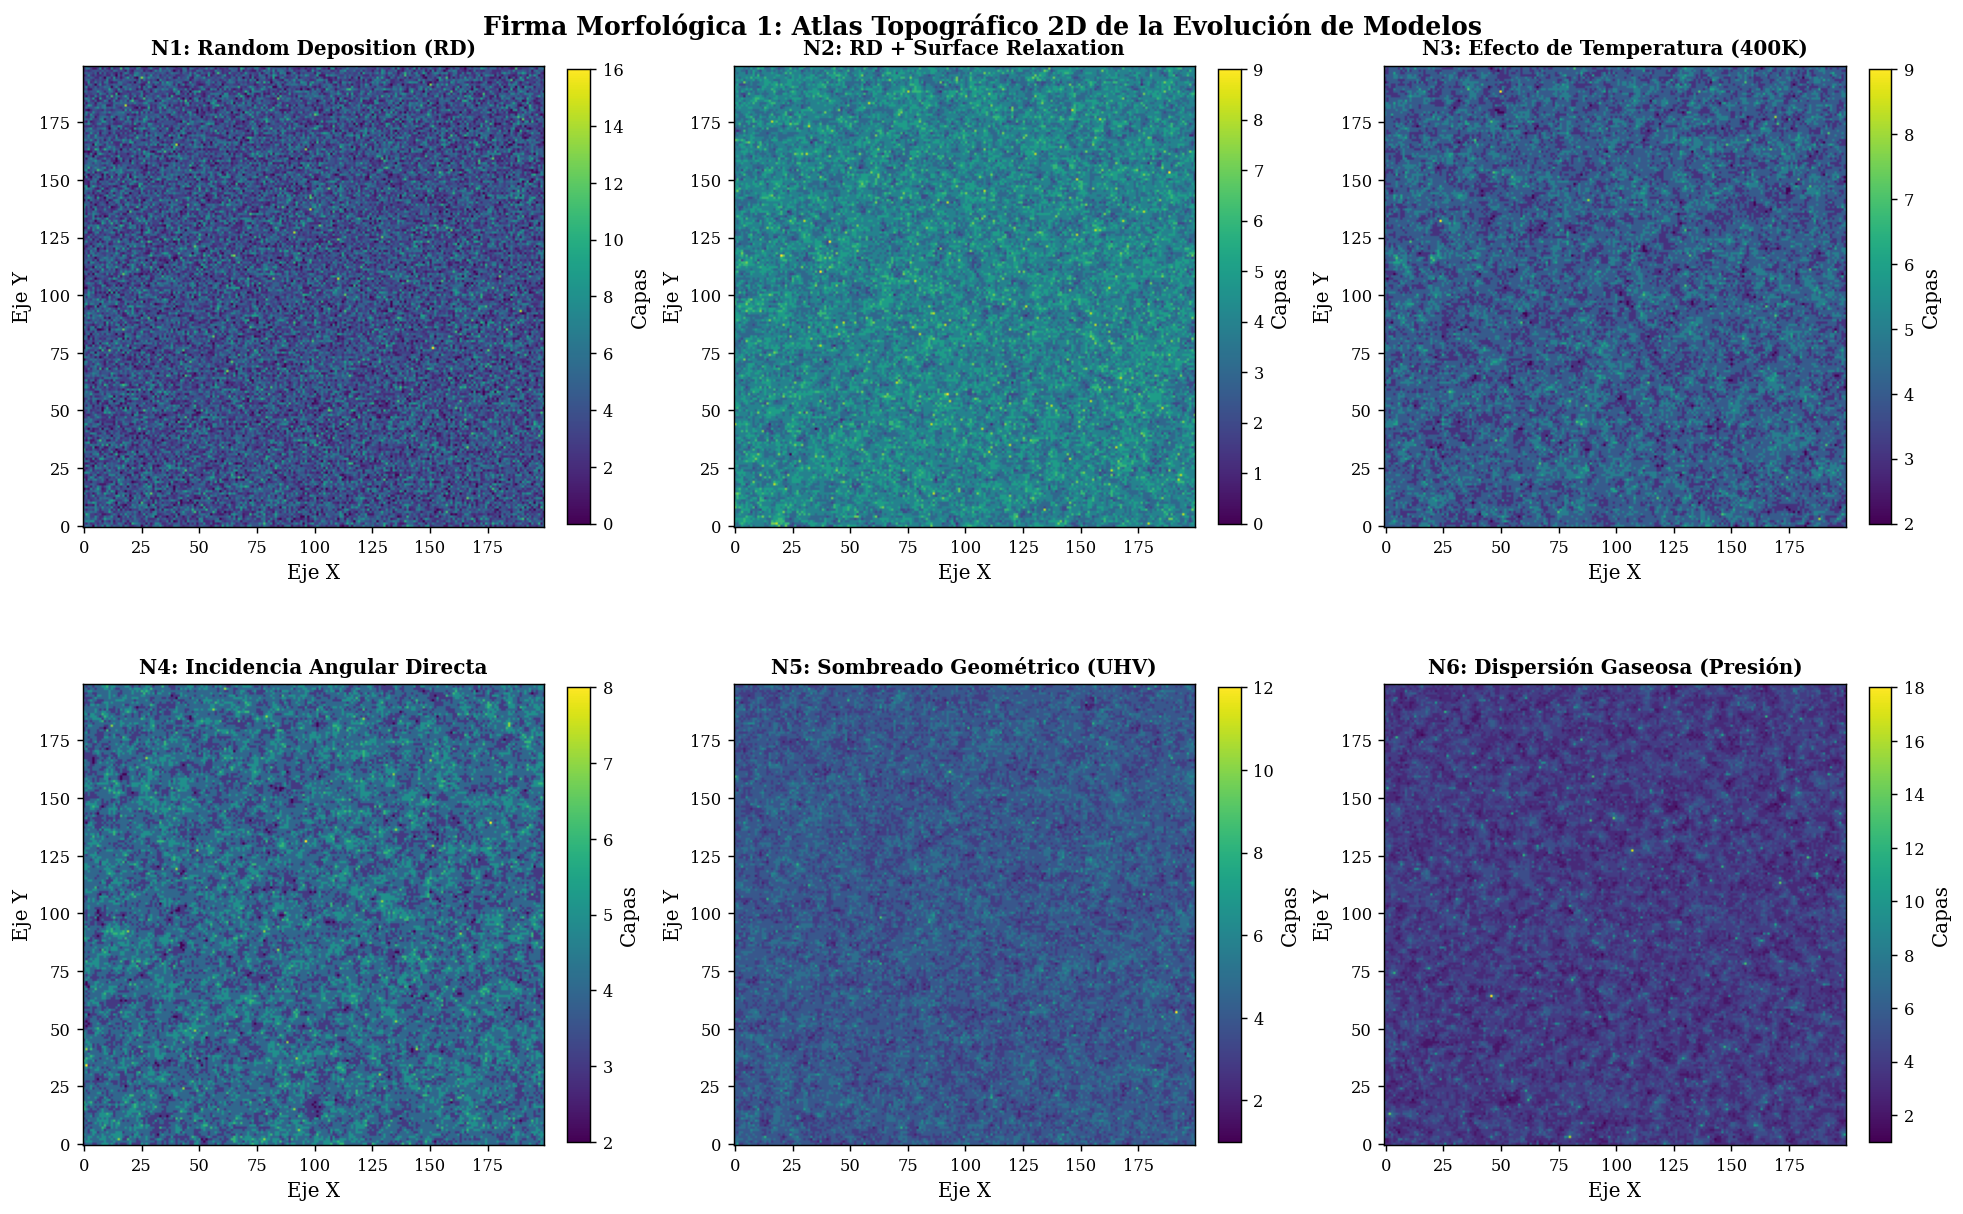

In [20]:
# =============================================================================
# SECCIÓN 8: ATLAS TOPOGRÁFICO 2D DE LOS SEIS MODELOS
# =============================================================================
# El atlas reúne, en una única figura, la superficie representativa (primera
# réplica) de cada uno de los seis regímenes físicos definidos en la Sección 6.
# La comparación visual directa entre paneles permite apreciar cómo cada
# mecanismo añadido modifica la topografía final de la película.

fig, axes = plt.subplots(2, 3, figsize=(15, 9.5), constrained_layout=True)
axes = axes.ravel()

for idx, (nombre, datos) in enumerate(RESULTADOS_MODELOS.items()):
    superficie = datos["superficie"]

    im = axes[idx].imshow(superficie, origin="lower", cmap="viridis")
    axes[idx].set_title(nombre, fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Eje X")
    axes[idx].set_ylabel("Eje Y")

    fig.colorbar(im, ax=axes[idx], shrink=0.75, label="Capas")

fig.suptitle("Firma Morfológica 1: Atlas Topográfico 2D de la Evolución de Modelos",
             fontweight="bold", y=0.98)

plt.savefig("unificado_atlas_2d.png", bbox_inches="tight")
plt.show()


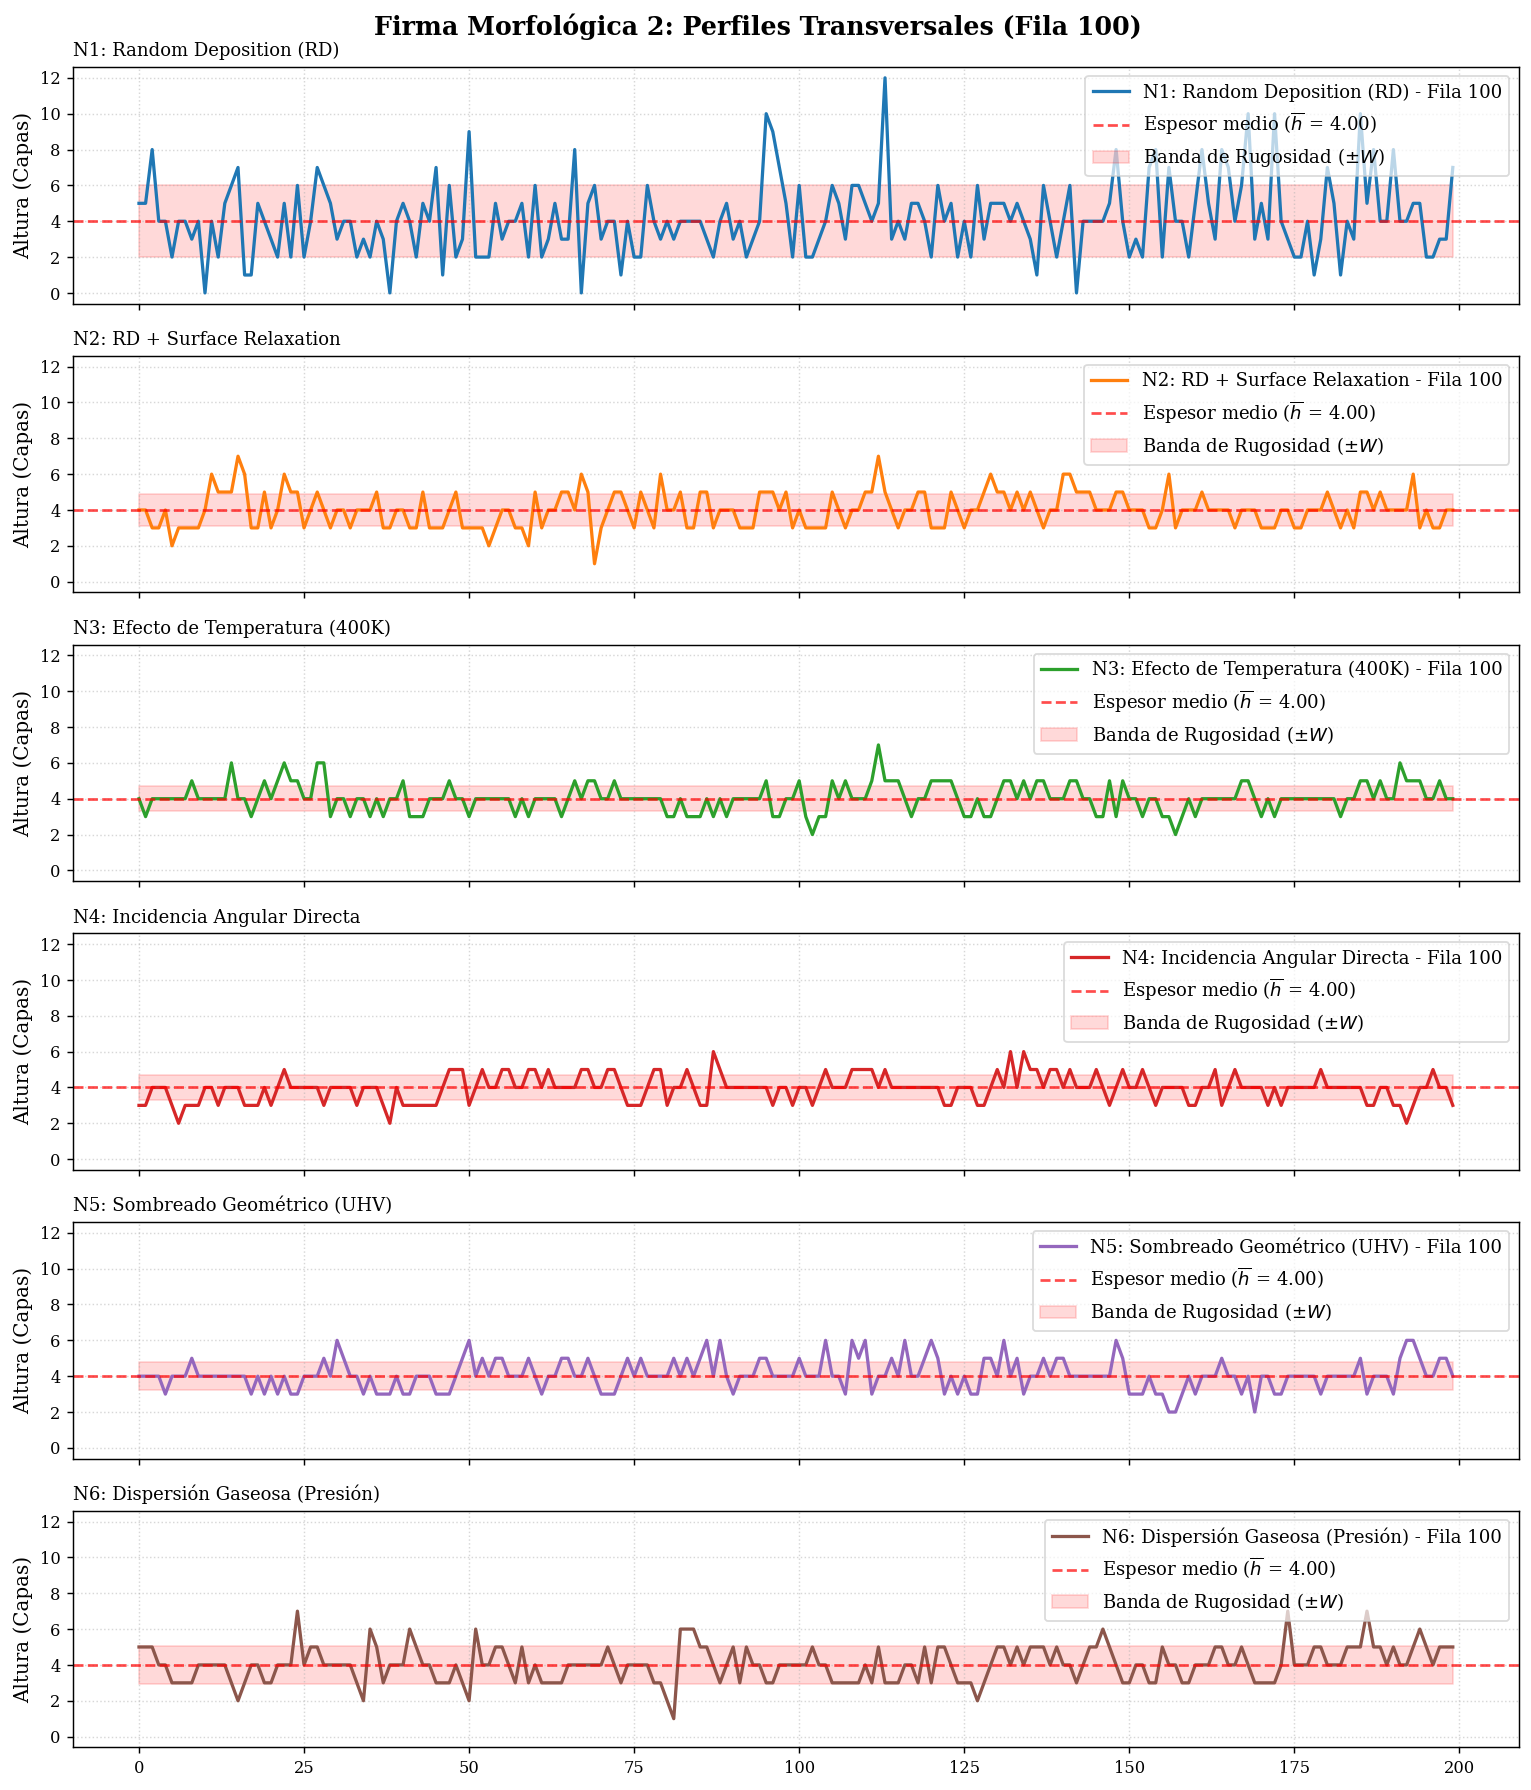

In [21]:
# =============================================================================
# SECCIÓN 9: PERFILES TRANSVERSALES REPRESENTATIVOS
# =============================================================================
# Se extrae la fila central (NX/2) de la superficie representativa de cada
# modelo para comparar, en una única dimensión, el contraste entre picos y
# valles. La línea roja marca el espesor medio de las 25 réplicas y la banda
# sombreada indica el intervalo (h̄ ± W), donde W es la rugosidad RMS
# correspondiente.

fila_c = NX // 2
colores = plt.cm.tab10.colors

fig, axes = plt.subplots(len(RESULTADOS_MODELOS), 1, figsize=(12, 14), sharex=True, sharey=True)

for ax, (nombre, datos), color in zip(axes, RESULTADOS_MODELOS.items(), colores):
    superficie = datos["superficie"]
    espesor    = np.mean(datos["espesores_finales"])
    rugosidad  = np.mean(datos["rugosidades_finales"])

    ax.plot(superficie[fila_c, :], lw=1.8, color=color, label=f"{nombre} - Fila {fila_c}")
    ax.axhline(espesor, color="red", linestyle="--", alpha=0.7,
               label=rf"Espesor medio ($\overline{{h}}$ = {espesor:.2f})")
    ax.fill_between(range(NX), espesor - rugosidad, espesor + rugosidad,
                    color="red", alpha=0.15, label=r"Banda de Rugosidad ($\pm W$)")

    ax.set_title(nombre, fontsize=10, loc="left")
    ax.set_ylabel("Altura (Capas)")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="upper right", framealpha=0.7)

fig.suptitle(f"Firma Morfológica 2: Perfiles Transversales (Fila {fila_c})", fontweight="bold")
plt.tight_layout()
plt.savefig("unificado_perfiles_subplots.png", bbox_inches="tight")
plt.show()


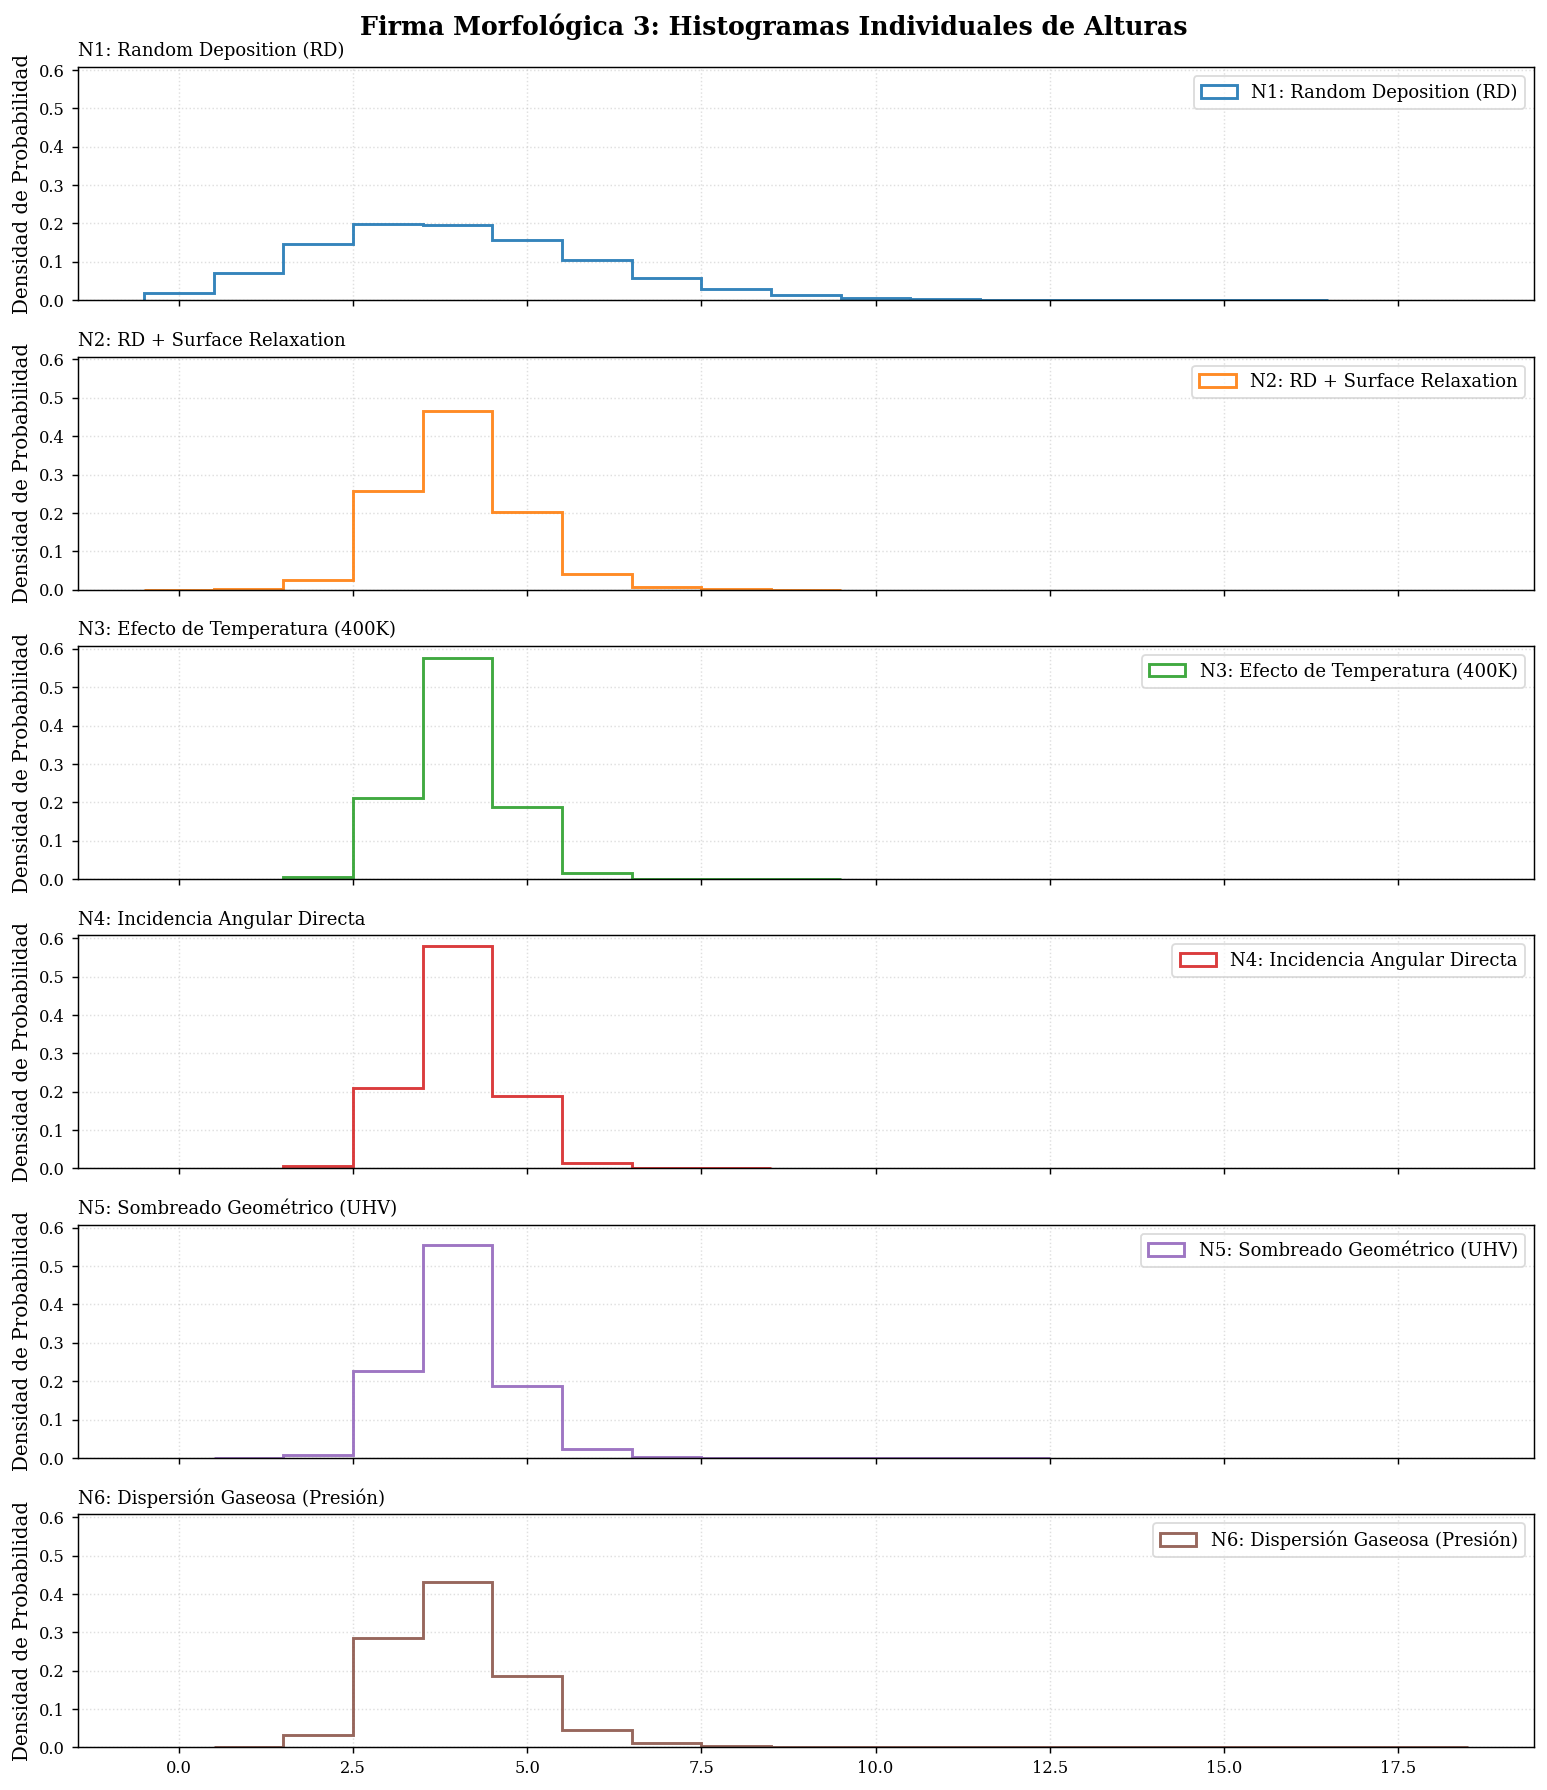

In [22]:
# =============================================================================
# SECCIÓN 9B: HISTOGRAMAS INDIVIDUALES DE ALTURAS
# =============================================================================
# La función de distribución de alturas de cada modelo se construye con bins
# centrados en valores enteros de capa (la superficie almacena conteos
# discretos de átomos depositados por sitio), lo que evita artefactos de
# agrupamiento en el histograma.

fig, axes = plt.subplots(len(RESULTADOS_MODELOS), 1, figsize=(12, 14), sharex=True, sharey=True)

for ax, (nombre, datos), color in zip(axes, RESULTADOS_MODELOS.items(), colores):
    superficie = datos["superficie"]
    bins = np.arange(superficie.min(), superficie.max() + 2) - 0.5

    ax.hist(superficie.ravel(), bins=bins, density=True, histtype="step",
            lw=1.6, color=color, alpha=0.9, label=nombre)

    ax.set_title(nombre, fontsize=10, loc="left")
    ax.set_ylabel("Densidad de Probabilidad")
    ax.grid(True, linestyle=":", alpha=0.4)
    ax.legend(loc="upper right", framealpha=0.7)

fig.suptitle("Firma Morfológica 3: Histogramas Individuales de Alturas", fontweight="bold")
plt.tight_layout()
plt.savefig("unificado_histogramas_subplots.png", bbox_inches="tight")
plt.show()


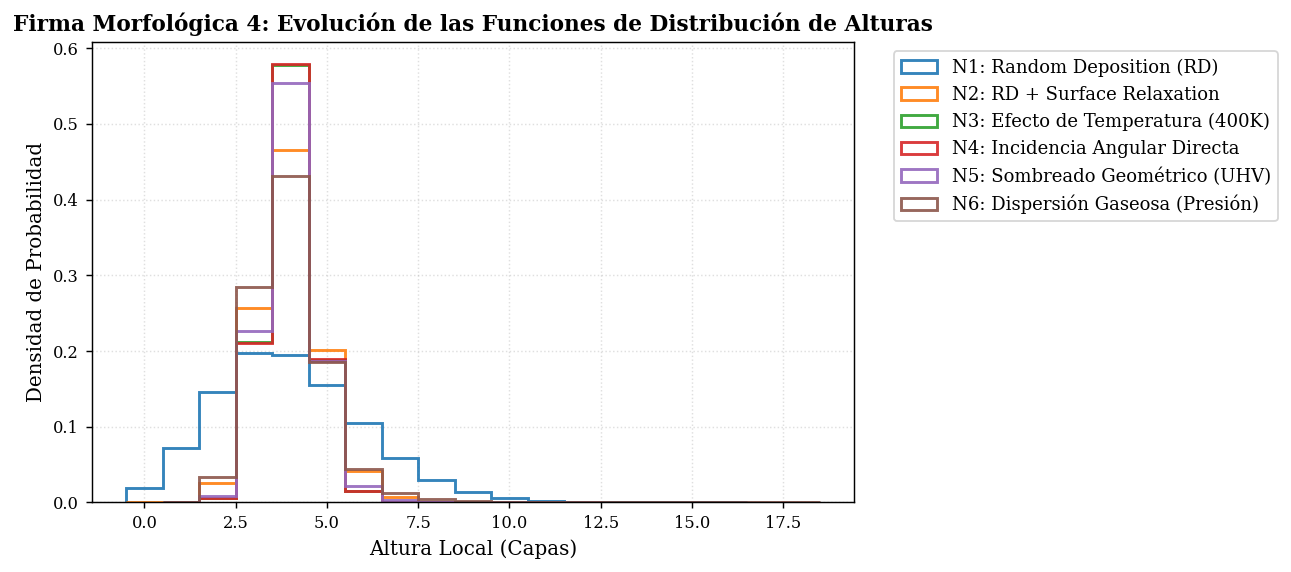

In [23]:
# =============================================================================
# SECCIÓN 9C: COMPARACIÓN CONJUNTA DE LAS DISTRIBUCIONES DE ALTURAS
# =============================================================================
# Superponer las seis distribuciones en un mismo eje permite comparar
# directamente su anchura relativa, que constituye la firma estadística de la
# rugosidad de cada régimen.

plt.figure(figsize=(10, 4.5))

for (nombre, datos), color in zip(RESULTADOS_MODELOS.items(), colores):
    superficie = datos["superficie"]
    bins = np.arange(superficie.min(), superficie.max() + 2) - 0.5
    plt.hist(superficie.ravel(), bins=bins, density=True, histtype="step",
             lw=1.6, alpha=0.9, color=color, label=nombre)

plt.title("Firma Morfológica 4: Evolución de las Funciones de Distribución de Alturas", fontweight="bold")
plt.xlabel("Altura Local (Capas)")
plt.ylabel("Densidad de Probabilidad")
plt.grid(True, linestyle=":", alpha=0.4)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()
plt.savefig("unificado_histogramas.png", bbox_inches="tight")
plt.show()


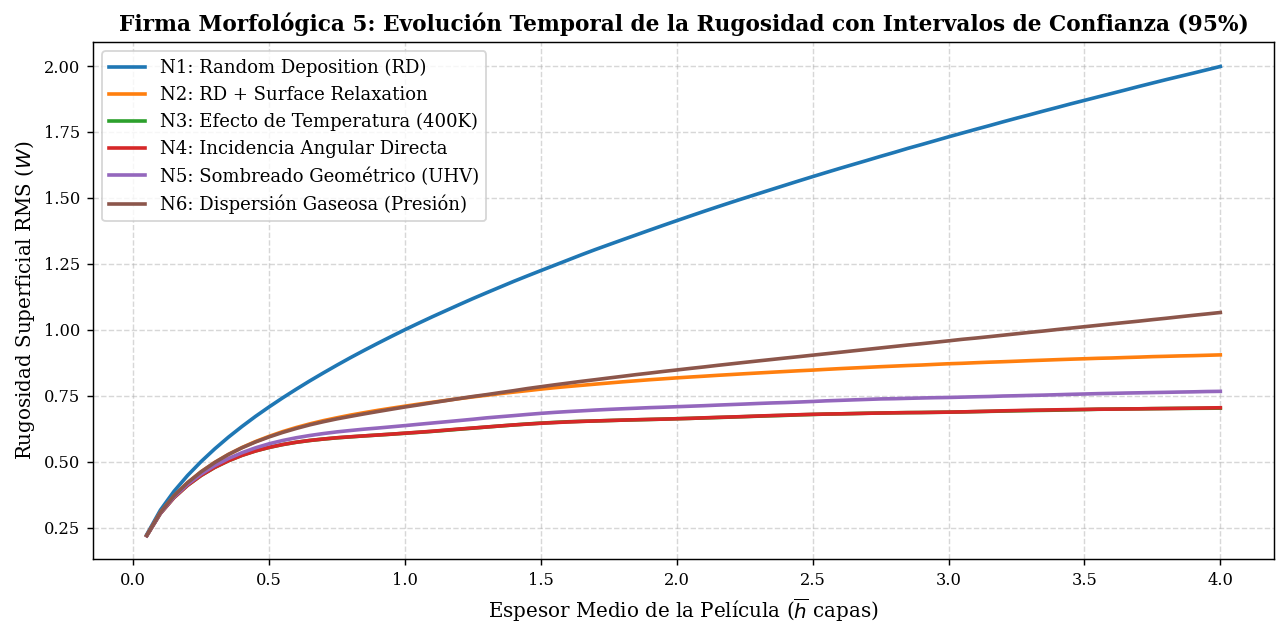

In [24]:
# =============================================================================
# SECCIÓN 10: EVOLUCIÓN TEMPORAL DE LA RUGOSIDAD CON INTERVALOS DE CONFIANZA
# =============================================================================
# Cada curva traza la rugosidad RMS promedio de las 25 réplicas en función del
# espesor medio de la película, con una banda de confianza del 95 % construida
# a partir del error estándar entre réplicas.

plt.figure(figsize=(10, 5))

for nombre, datos in RESULTADOS_MODELOS.items():
    espesor   = datos["espesor_promedio"]
    rugosidad = datos["rugosidad_promedio"]
    ic95      = datos["ic95_rugosidad"]

    plt.plot(espesor, rugosidad, lw=2, label=nombre)
    plt.fill_between(espesor, rugosidad - ic95, rugosidad + ic95, alpha=0.20)

plt.title(r"Firma Morfológica 5: Evolución Temporal de la Rugosidad "
          r"con Intervalos de Confianza (95%)", fontweight="bold")
plt.xlabel(r"Espesor Medio de la Película ($\overline{h}$ capas)")
plt.ylabel(r"Rugosidad Superficial RMS ($W$)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("unificado_cinetica_rugosidad_ic95.png", bbox_inches="tight")
plt.show()


In [25]:
# =============================================================================
# SECCIÓN 10B: ESTADÍSTICA DESCRIPTIVA DE LAS CINÉTICAS FINALES
# =============================================================================
# Resume, para cada modelo, el espesor y la rugosidad final promediados sobre
# las 25 réplicas, junto con sus desviaciones estándar, errores estándar e
# intervalos de confianza del 95 %.

print("\n========================================================")
print("RESUMEN ESTADÍSTICO DE LAS CINÉTICAS")
print("========================================================")

tabla_estadistica = []

for nombre, datos in RESULTADOS_MODELOS.items():
    rug_final = datos["rugosidades_finales"]
    esp_final = datos["espesores_finales"]

    tabla_estadistica.append({
        "Modelo": nombre,
        "Espesor Medio": np.mean(esp_final),
        "Std Espesor": np.std(esp_final, ddof=1),
        "Rugosidad Media": np.mean(rug_final),
        "Std Rugosidad": np.std(rug_final, ddof=1),
        "Error Estándar": np.std(rug_final, ddof=1) / np.sqrt(REPLICAS_POR_MODELO),
        "IC95": 1.96 * np.std(rug_final, ddof=1) / np.sqrt(REPLICAS_POR_MODELO)
    })

df_estadistica = pd.DataFrame(tabla_estadistica)
display(df_estadistica.round(4))



RESUMEN ESTADÍSTICO DE LAS CINÉTICAS


,Modelo,Espesor Medio,Std Espesor,Rugosidad Media,Std Rugosidad,Error Estándar,IC95
0,N1: Random Deposition (RD),4.0,0.0,1.9983,0.0062,0.0012,0.0024
1,N2: RD + Surface Relaxation,4.0,0.0,0.9046,0.0041,0.0008,0.0016
2,N3: Efecto de Temperatura (400K),4.0,0.0,0.7026,0.0033,0.0007,0.0013
3,N4: Incidencia Angular Directa,4.0,0.0,0.7041,0.0033,0.0007,0.0013
4,N5: Sombreado Geométrico (UHV),4.0,0.0,0.7663,0.0046,0.0009,0.0018
5,N6: Dispersión Gaseosa (Presión),4.0,0.0,1.0653,0.0093,0.0019,0.0036



Calculando exponentes de crecimiento dinámico (β)...


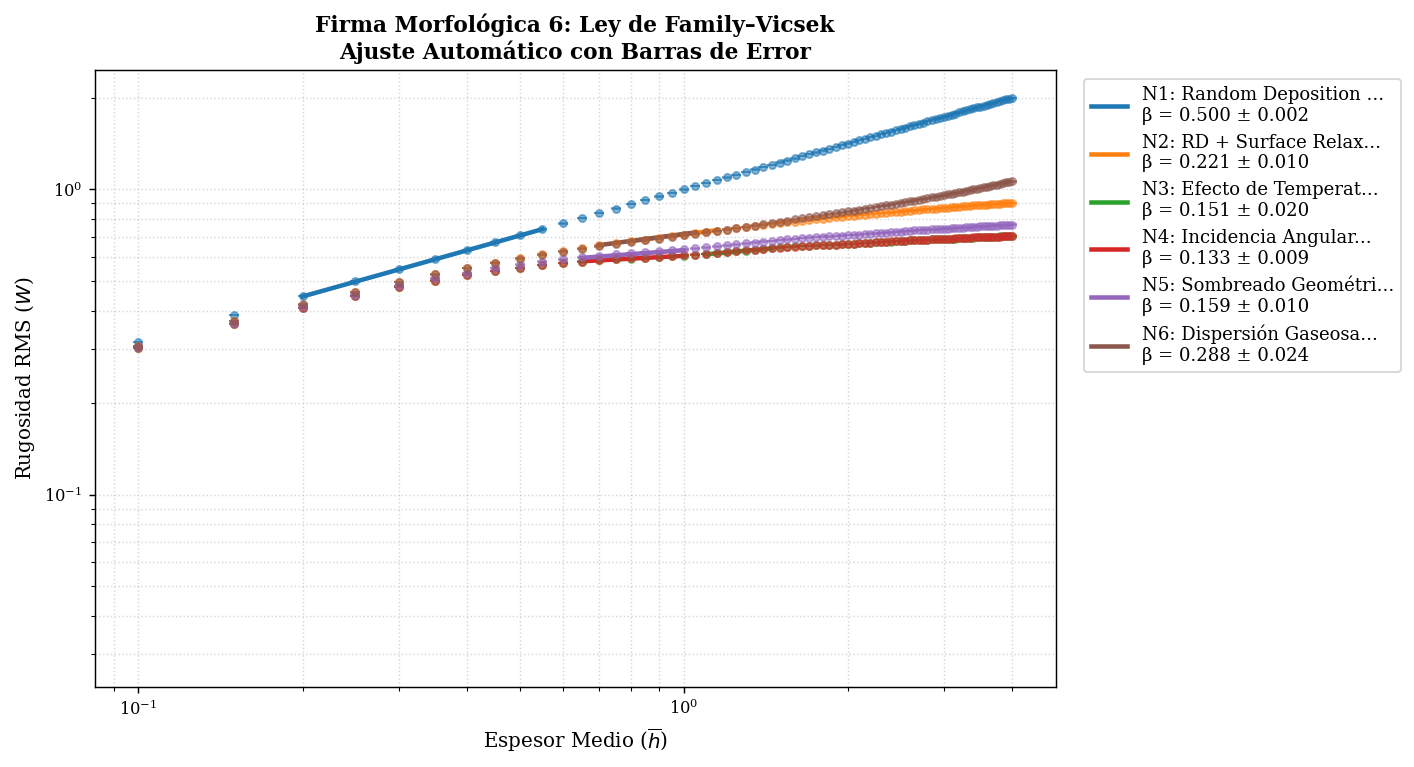


MATRIZ CUANTITATIVA DE CRECIMIENTO DINÁMICO


,Modelo,Rugosidad Final,ΔH,β,Std β,IC95 β,R²
0,N1: Random Deposition (RD),1.9983,14.80,0.5001,0.0062,0.0024,1.0000
1,N2: RD + Surface Relaxation,0.9046,9.44,0.2214,0.0253,0.0099,0.9999
2,N3: Efecto de Temperatura (400K),0.7026,6.60,0.1508,0.0509,0.0200,0.9992
3,N4: Incidencia Angular Directa,0.7041,6.56,0.1334,0.0232,0.0091,0.9994
4,N5: Sombreado Geométrico (UHV),0.7663,9.40,0.1588,0.0268,0.0105,0.9997
5,N6: Dispersión Gaseosa (Presión),1.0653,17.48,0.2875,0.0612,0.0240,0.9999


In [26]:
# =============================================================================
# SECCIÓN 10C: EXTRACCIÓN CUANTITATIVA DE LA LEY DE ESCALA DE FAMILY–VICSEK
# =============================================================================
# Para cada modelo se estima el exponente de crecimiento dinámico β mediante
# una regresión lineal en el espacio log-log de la relación W ∝ h̄^β
# (Family & Vicsek, 1985). Dentro de la región de crecimiento de cada réplica
# se recorre una ventana deslizante de tamaño fijo y se conserva la posición
# que maximiza el coeficiente de determinación R² del ajuste.

def ajustar_exponente_dinamico_replica(log_h, log_w, ventana):
    """
    Busca, dentro de una réplica individual, la ventana contigua de tamaño
    fijo que maximiza el R² de la regresión lineal log(W) frente a log(h̄).

    Devuelve la pendiente (beta), el intercepto, el R² del mejor ajuste y los
    índices de inicio y fin de la ventana ganadora, que se emplean después
    para trazar la recta de ajuste representativa del modelo.
    """
    mejor_r2, mejor_beta, mejor_intercepto, mejor_inicio, mejor_fin = -np.inf, None, None, None, None
    for inicio in range(len(log_h) - ventana):
        fin = inicio + ventana
        pendiente, intercepto, r, _, _ = stats.linregress(log_h[inicio:fin], log_w[inicio:fin])
        if r**2 > mejor_r2:
            mejor_r2, mejor_beta, mejor_intercepto, mejor_inicio, mejor_fin = r**2, pendiente, intercepto, inicio, fin
    return mejor_beta, mejor_intercepto, mejor_r2, mejor_inicio, mejor_fin


print("\nCalculando exponentes de crecimiento dinámico (β)...")

tabla_escalamiento_fv = []
plt.figure(figsize=(11, 6))

VENTANA_AJUSTE = 8
colores = plt.cm.tab10.colors

for color, (nombre, datos) in zip(colores, RESULTADOS_MODELOS.items()):
    historias_h, historias_w = datos["historias_espesor"], datos["historias_rugosidad"]
    beta_replicas, mejor_r2_global = [], -np.inf
    mejor_inicio_global = mejor_fin_global = mejor_beta_global = mejor_intercepto_global = None

    # Se calcula un β independiente por réplica, descartando los primeros
    # instantes de la deposición (h̄ ≤ 0.10, W ≤ 0.01), donde el ruido
    # estadístico domina sobre la tendencia física.
    for h, w in zip(historias_h, historias_w):
        mascara = (h > 0.10) & (w > 0.01)
        log_h, log_w = np.log(h[mascara]), np.log(w[mascara])

        beta, intercepto, r2, inicio, fin = ajustar_exponente_dinamico_replica(
            log_h, log_w, VENTANA_AJUSTE
        )
        beta_replicas.append(beta)
        if r2 > mejor_r2_global:
            mejor_r2_global, mejor_beta_global, mejor_intercepto_global = r2, beta, intercepto
            mejor_inicio_global, mejor_fin_global = inicio, fin

    beta_replicas = np.array(beta_replicas)
    beta_media, beta_std = np.mean(beta_replicas), np.std(beta_replicas, ddof=1)
    beta_error, beta_ic95 = beta_std / np.sqrt(REPLICAS_POR_MODELO), 1.96 * (beta_std / np.sqrt(REPLICAS_POR_MODELO))

    # -------------------------------------------------------------------
    # Curva promedio de espesor y rugosidad, usada para la gráfica y el
    # ajuste representativo del modelo
    # -------------------------------------------------------------------
    h, w, ic95 = datos["espesor_promedio"], datos["rugosidad_promedio"], datos["ic95_rugosidad"]
    mascara = (h > 0.10) & (w > 0.01)
    h_fit, w_fit, ic95 = h[mascara], w[mascara], ic95[mascara]

    plt.errorbar(h_fit, w_fit, yerr=ic95, fmt='o', ms=4, capsize=3, alpha=0.55, color=color)

    h_linea = h_fit[mejor_inicio_global:mejor_fin_global]
    plt.loglog(h_linea, np.exp(mejor_intercepto_global) * h_linea**mejor_beta_global,
               lw=2.5, color=color, label=f"{nombre[:22]}...\nβ = {beta_media:.3f} ± {beta_ic95:.3f}")

    delta_h = np.mean(datos["maximos_finales"]) - np.mean(datos["minimos_finales"])
    tabla_escalamiento_fv.append({
        "Modelo": nombre,
        "Rugosidad Final": np.mean(datos["rugosidades_finales"]),
        "ΔH": delta_h,
        "β": beta_media,
        "Std β": beta_std,
        "IC95 β": beta_ic95,
        "R²": mejor_r2_global
    })

plt.title("Firma Morfológica 6: Ley de Family–Vicsek\nAjuste Automático con Barras de Error", fontweight="bold")
plt.xlabel(r"Espesor Medio ($\overline{h}$)")
plt.ylabel(r"Rugosidad RMS ($W$)")
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("unificado_family_vicsek_estadistico.png", bbox_inches="tight")
plt.show()

df_fv = pd.DataFrame(tabla_escalamiento_fv)
print("\n===================================================================")
print("MATRIZ CUANTITATIVA DE CRECIMIENTO DINÁMICO")
print("===================================================================")
display(df_fv.round(4))


# 11. ANÁLISIS DE RESULTADOS

Los resultados obtenidos permiten evaluar de manera sistemática la influencia de los diferentes mecanismos físicos implementados sobre la evolución morfológica de las películas delgadas simuladas mediante el método Monte Carlo. La combinación de mapas topográficos, perfiles transversales, distribuciones de alturas, evolución temporal de la rugosidad y análisis de escalamiento dinámico proporciona una caracterización tanto cualitativa como cuantitativa del crecimiento superficial.

## Resumen de los principales hallazgos

A continuación se resumen las tendencias generales observadas en la suite comparativa:

- El modelo de **Random Deposition (RD)** reproduce el comportamiento esperado para una deposición completamente aleatoria, con un exponente dinámico β≈0.50 que coincide con la predicción teórica de su clase de universalidad (Family & Vicsek, 1985).
- La incorporación de **relajación superficial** produce la reducción más importante de la rugosidad entre todos los mecanismos estudiados, disminuyendo tanto el valor final de W como la velocidad con la que crecen las fluctuaciones superficiales.
- La inclusión de una **temperatura** más alta incrementa la movilidad efectiva de las partículas depositadas, lo que se traduce en una disminución adicional de la rugosidad respecto al modelo con relajación superficial únicamente.
- Bajo las condiciones de simulación empleadas, la **incidencia angular** modifica ligeramente la distribución espacial del material depositado, sin apartarse de forma apreciable de la rugosidad obtenida con el modelo térmico.
- El **sombreado geométrico** incrementa moderadamente la rugosidad frente a los modelos dominados por difusión superficial, evidenciando la aparición de un mecanismo de retroalimentación geométrica positiva durante el crecimiento (Karunasiri et al., 1989).
- La **dispersión gaseosa** introduce variaciones pequeñas respecto al modelo con sombreado geométrico, lo que indica que, para los parámetros de presión considerados, este mecanismo desempeña un papel secundario frente a la rugosidad global.

En conjunto, estos resultados muestran que la relajación superficial es el mecanismo que domina la evolución morfológica del sistema, mientras que los mecanismos incorporados después producen modificaciones adicionales de menor magnitud, consistentes con la jerarquía de clases de universalidad descrita en la Sección 1.3 (Barabási & Stanley, 1995).

---

## Evolución morfológica

El atlas topográfico evidencia una transformación progresiva de la superficie a medida que se incorporan nuevos mecanismos físicos.

El modelo RD presenta una distribución de alturas completamente aleatoria, con elevada dispersión y ausencia de correlación espacial apreciable entre columnas vecinas. Al incorporar relajación superficial, la topografía se vuelve considerablemente más homogénea: las partículas pueden desplazarse hacia posiciones localmente más estables antes de quedar fijadas, lo que reduce la formación de picos pronunciados. La temperatura más alta favorece este mismo mecanismo al incrementar la probabilidad de salto superficial, con la consiguiente disminución adicional de la rugosidad.

La incidencia angular introduce, en cambio, una ligera anisotropía en la deposición sin alterar de forma importante la rugosidad global. El sombreado geométrico y la dispersión gaseosa producen modificaciones adicionales en la textura de la superficie, aunque de magnitud moderada bajo las condiciones consideradas en esta suite.

Los perfiles transversales corroboran estas observaciones: la reducción de las fluctuaciones al pasar del modelo RD al modelo con relajación superficial es mucho más marcada que las diferencias observadas entre los mecanismos incorporados con posterioridad.

---

## Distribuciones estadísticas de alturas

Las funciones de distribución de alturas permiten cuantificar estadísticamente la morfología obtenida en cada modelo. El modelo RD presenta la distribución más ancha de toda la suite, reflejo directo de la ausencia de un mecanismo que suavice las fluctuaciones durante el crecimiento. Todos los modelos que incorporan relajación superficial muestran, en contraste, distribuciones considerablemente más estrechas.

Las diferencias entre los modelos con temperatura, incidencia angular, sombreado geométrico y dispersión gaseosa son relativamente pequeñas entre sí, lo que confirma que la relajación superficial continúa siendo el mecanismo predominante en la determinación de la rugosidad global. Este resultado es coherente con las observaciones obtenidas a partir de las superficies bidimensionales y de los perfiles longitudinales.

---

## Evolución temporal de la rugosidad

Las curvas cinéticas muestran diferencias claras en la velocidad con la que crece la rugosidad superficial en el tiempo. El modelo RD presenta el crecimiento más rápido, mientras que la relajación superficial reduce notablemente esa velocidad. La temperatura disminuye ligeramente la rugosidad respecto al caso con relajación pura, y la incidencia angular mantiene una evolución prácticamente equivalente a esta última.

Los modelos con sombreado geométrico y dispersión gaseosa presentan un incremento moderado de la rugosidad respecto a los regímenes dominados exclusivamente por difusión superficial. Las bandas de confianza del 95 % permanecen estrechas durante toda la simulación, lo que indica una buena reproducibilidad de las 25 realizaciones Monte Carlo por modelo y confirma que las diferencias observadas entre modelos son considerablemente mayores que la incertidumbre estadística asociada al método.

---

## Escalamiento dinámico (ley de Family–Vicsek)

El ajuste en escala logarítmica permitió estimar el exponente dinámico β para cada uno de los seis modelos. El modelo RD reproduce el valor teórico esperado, β≈0.50, lo que valida tanto la implementación del motor Monte Carlo como la metodología empleada para extraer el exponente. La incorporación de relajación superficial reduce β hasta aproximadamente 0.22, una disminución sustancial en la velocidad de crecimiento de la rugosidad. Los modelos con temperatura, incidencia angular, sombreado geométrico y dispersión gaseosa presentan valores de β comprendidos entre aproximadamente 0.14 y 0.17, todos ellos significativamente inferiores al caso RD.

Estos valores corresponden al modelo mesoscópico simplificado desarrollado en este trabajo y no deben interpretarse como constantes universales asociadas a sistemas experimentales específicos.

---

## Discusión física

En conjunto, los resultados indican que la movilidad superficial es el mecanismo con mayor influencia sobre la evolución morfológica del sistema. La relajación superficial permite que las partículas depositadas ocupen posiciones energéticamente más favorables, reduciendo los gradientes locales de altura y limitando el crecimiento de la rugosidad; la temperatura incrementa la eficacia de este proceso al aumentar la probabilidad de salto superficial.

La incidencia angular modifica principalmente la dirección de llegada de las partículas, sin producir cambios apreciables en la rugosidad global bajo los parámetros utilizados. El sombreado geométrico añade un mecanismo de retroalimentación positiva que incrementa moderadamente la rugosidad, mientras que la dispersión gaseosa altera parcialmente las trayectorias incidentes sin modificar de forma significativa los indicadores morfológicos obtenidos para estos parámetros de presión.

Finalmente, la incorporación de réplicas estadísticas independientes, junto con el cálculo de desviaciones estándar, errores estándar e intervalos de confianza del 95 % tanto para la rugosidad como para el exponente β, permite cuantificar explícitamente la incertidumbre inherente al método Monte Carlo y fortalece la validez de las comparaciones realizadas entre los seis modelos.


# 12. CONCLUSIONES

En este trabajo se desarrolló un marco unificado de simulación Monte Carlo capaz de integrar progresivamente los principales mecanismos físicos estudiados en los notebooks anteriores para modelar el crecimiento de películas delgadas mediante deposición física en fase vapor.

La arquitectura implementada permitió incorporar en un único entorno de simulación procesos de deposición aleatoria, relajación superficial, difusión térmica, incidencia angular, sombreado geométrico y dispersión gaseosa, facilitando la comparación directa entre ellos bajo un conjunto común de parámetros y condiciones de simulación.

Los resultados obtenidos muestran que el modelo reproduce correctamente las tendencias cualitativas esperadas para este tipo de sistemas. En particular, el modelo de Random Deposition recupera el comportamiento clásico con un exponente dinámico β≈0.50, mientras que la incorporación de relajación superficial constituye el cambio más importante en la evolución morfológica, reduciendo significativamente la rugosidad y ralentizando el crecimiento de las fluctuaciones superficiales.

La temperatura produce una disminución adicional de la rugosidad respecto al modelo con relajación, mientras que la incidencia angular mantiene un comportamiento muy similar bajo las condiciones analizadas. Por su parte, el sombreado geométrico incrementa moderadamente la rugosidad, y la dispersión gaseosa introduce únicamente pequeñas modificaciones adicionales en comparación con dicho modelo.

La incorporación de herramientas estadísticas representa una mejora importante respecto a las versiones anteriores del proyecto. El uso de múltiples réplicas independientes, junto con el cálculo de desviaciones estándar, errores estándar, intervalos de confianza del 95 % y estimaciones estadísticas del exponente β, permite cuantificar explícitamente la incertidumbre de las simulaciones y proporciona mayor solidez a las comparaciones entre modelos.

Debe enfatizarse que el presente trabajo corresponde a un modelo mesoscópico simplificado cuyo objetivo principal es reproducir tendencias físicas generales y no describir de forma atomística procesos reales de deposición. En consecuencia, los valores numéricos obtenidos deben interpretarse como propiedades del modelo implementado y no como constantes universales de materiales específicos.

En conjunto, el notebook desarrollado constituye una plataforma computacional organizada, reproducible y estadísticamente consistente para estudiar la influencia de diferentes mecanismos físicos sobre la evolución morfológica de películas delgadas, representando además una base sólida para futuras extensiones del modelo.

Como trabajo futuro, esta plataforma puede ampliarse mediante la incorporación de barreras de Ehrlich–Schwoebel, funciones de correlación espacial, análisis mediante factores de estructura, cálculo de exponentes de rugosidad y crecimiento, estudios de convergencia respecto al tamaño del sistema y al número de partículas depositadas, así como modelos energéticos más realistas para la difusión superficial. Estas extensiones permitirían aproximar progresivamente el modelo a simulaciones utilizadas en investigación sobre crecimiento de superficies y películas delgadas.

# 13. REFERENCIAS

**Fuentes académicas primarias**

* Arrhenius, S. (1889). Über die Reaktionsgeschwindigkeit bei der Inversion von Rohrzucker durch Säuren. *Zeitschrift für Physikalische Chemie, 4*, 226 (no fue posible confirmar el rango de páginas exacto de la edición original).
* Family, F., & Vicsek, T. (1985). Scaling of the active zone in the Eden process on percolation networks and the ballistic deposition model. *Journal of Physics A: Mathematical and General, 18*(2), L75–L81. https://doi.org/10.1088/0305-4470/18/2/005
* Karunasiri, R. P. U., Bruinsma, R., & Rudnick, J. (1989). Thin-film growth and the shadow instability. *Physical Review Letters, 62*(7), 788–791. https://doi.org/10.1103/PhysRevLett.62.788
* Nieuwenhuizen, J. M., & Haanstra, H. B. (1966). Microfractography of thin films. *Philips Technical Review, 27*, 87–91.
* Ohring, M. (2002). *Materials science of thin films: Deposition and structure* (2nd ed.). Academic Press.

**Recursos complementarios**

* Barabási, A.-L., & Stanley, H. E. (1995). *Fractal concepts in surface growth*. Cambridge University Press.
* Venables, J. A. (2000). *Introduction to surface and thin film processes*. Cambridge University Press.
